## Agenda:
- Problem Formulation
- Loading the Raw Data from Kaggle
- Data Pre-processing
- Running XGBoost
- Hyperparameter Tuning
- Storing Models and Results
- Streamlit App

## Load the raw Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import pickle
import plotly.express as px
import streamlit as st
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()                 

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Data Pre-Processing

In [5]:
for column in df:
    unique_val = np.unique(df[column].fillna('0'))
    nr_value = len(unique_val)
    if nr_value <= 2:
         print('The number of values for feature {} :{} -- {}'.format(column, nr_value,unique_val))
    else:
        print('The number of values for feature {} :{}'.format(column, nr_value))
        

The number of values for feature RowNumber :10000
The number of values for feature CustomerId :10000
The number of values for feature Surname :2932
The number of values for feature CreditScore :460
The number of values for feature Geography :3
The number of values for feature Gender :2 -- ['Female' 'Male']
The number of values for feature Age :70
The number of values for feature Tenure :11
The number of values for feature Balance :6382
The number of values for feature NumOfProducts :4
The number of values for feature HasCrCard :2 -- [0 1]
The number of values for feature IsActiveMember :2 -- [0 1]
The number of values for feature EstimatedSalary :9999
The number of values for feature Exited :2 -- [0 1]


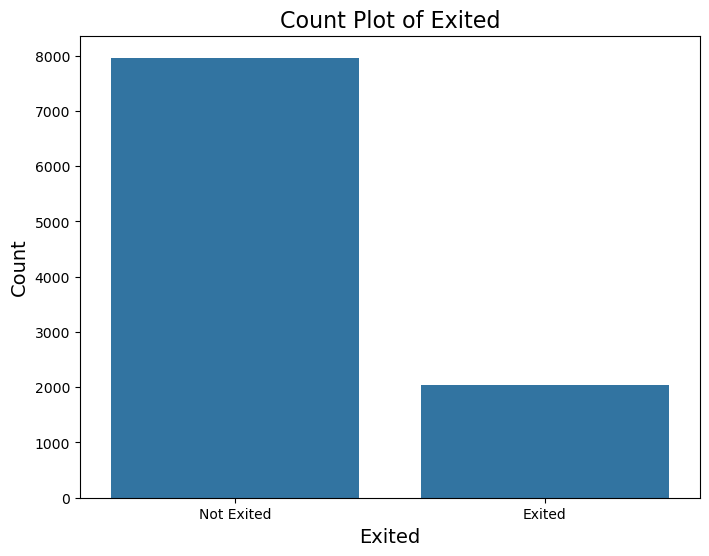

In [6]:
# visualizing the data

# count plot of our Y check the balance of dataset
plt.figure(figsize=(8,6))
sns.countplot(data=df,x='Exited')
plt.title("Count Plot of Exited",fontsize=16)
plt.xlabel("Exited",fontsize=14)
plt.ylabel("Count",fontsize=14)
plt.xticks([0,1],labels=['Not Exited','Exited'])
plt.show()          

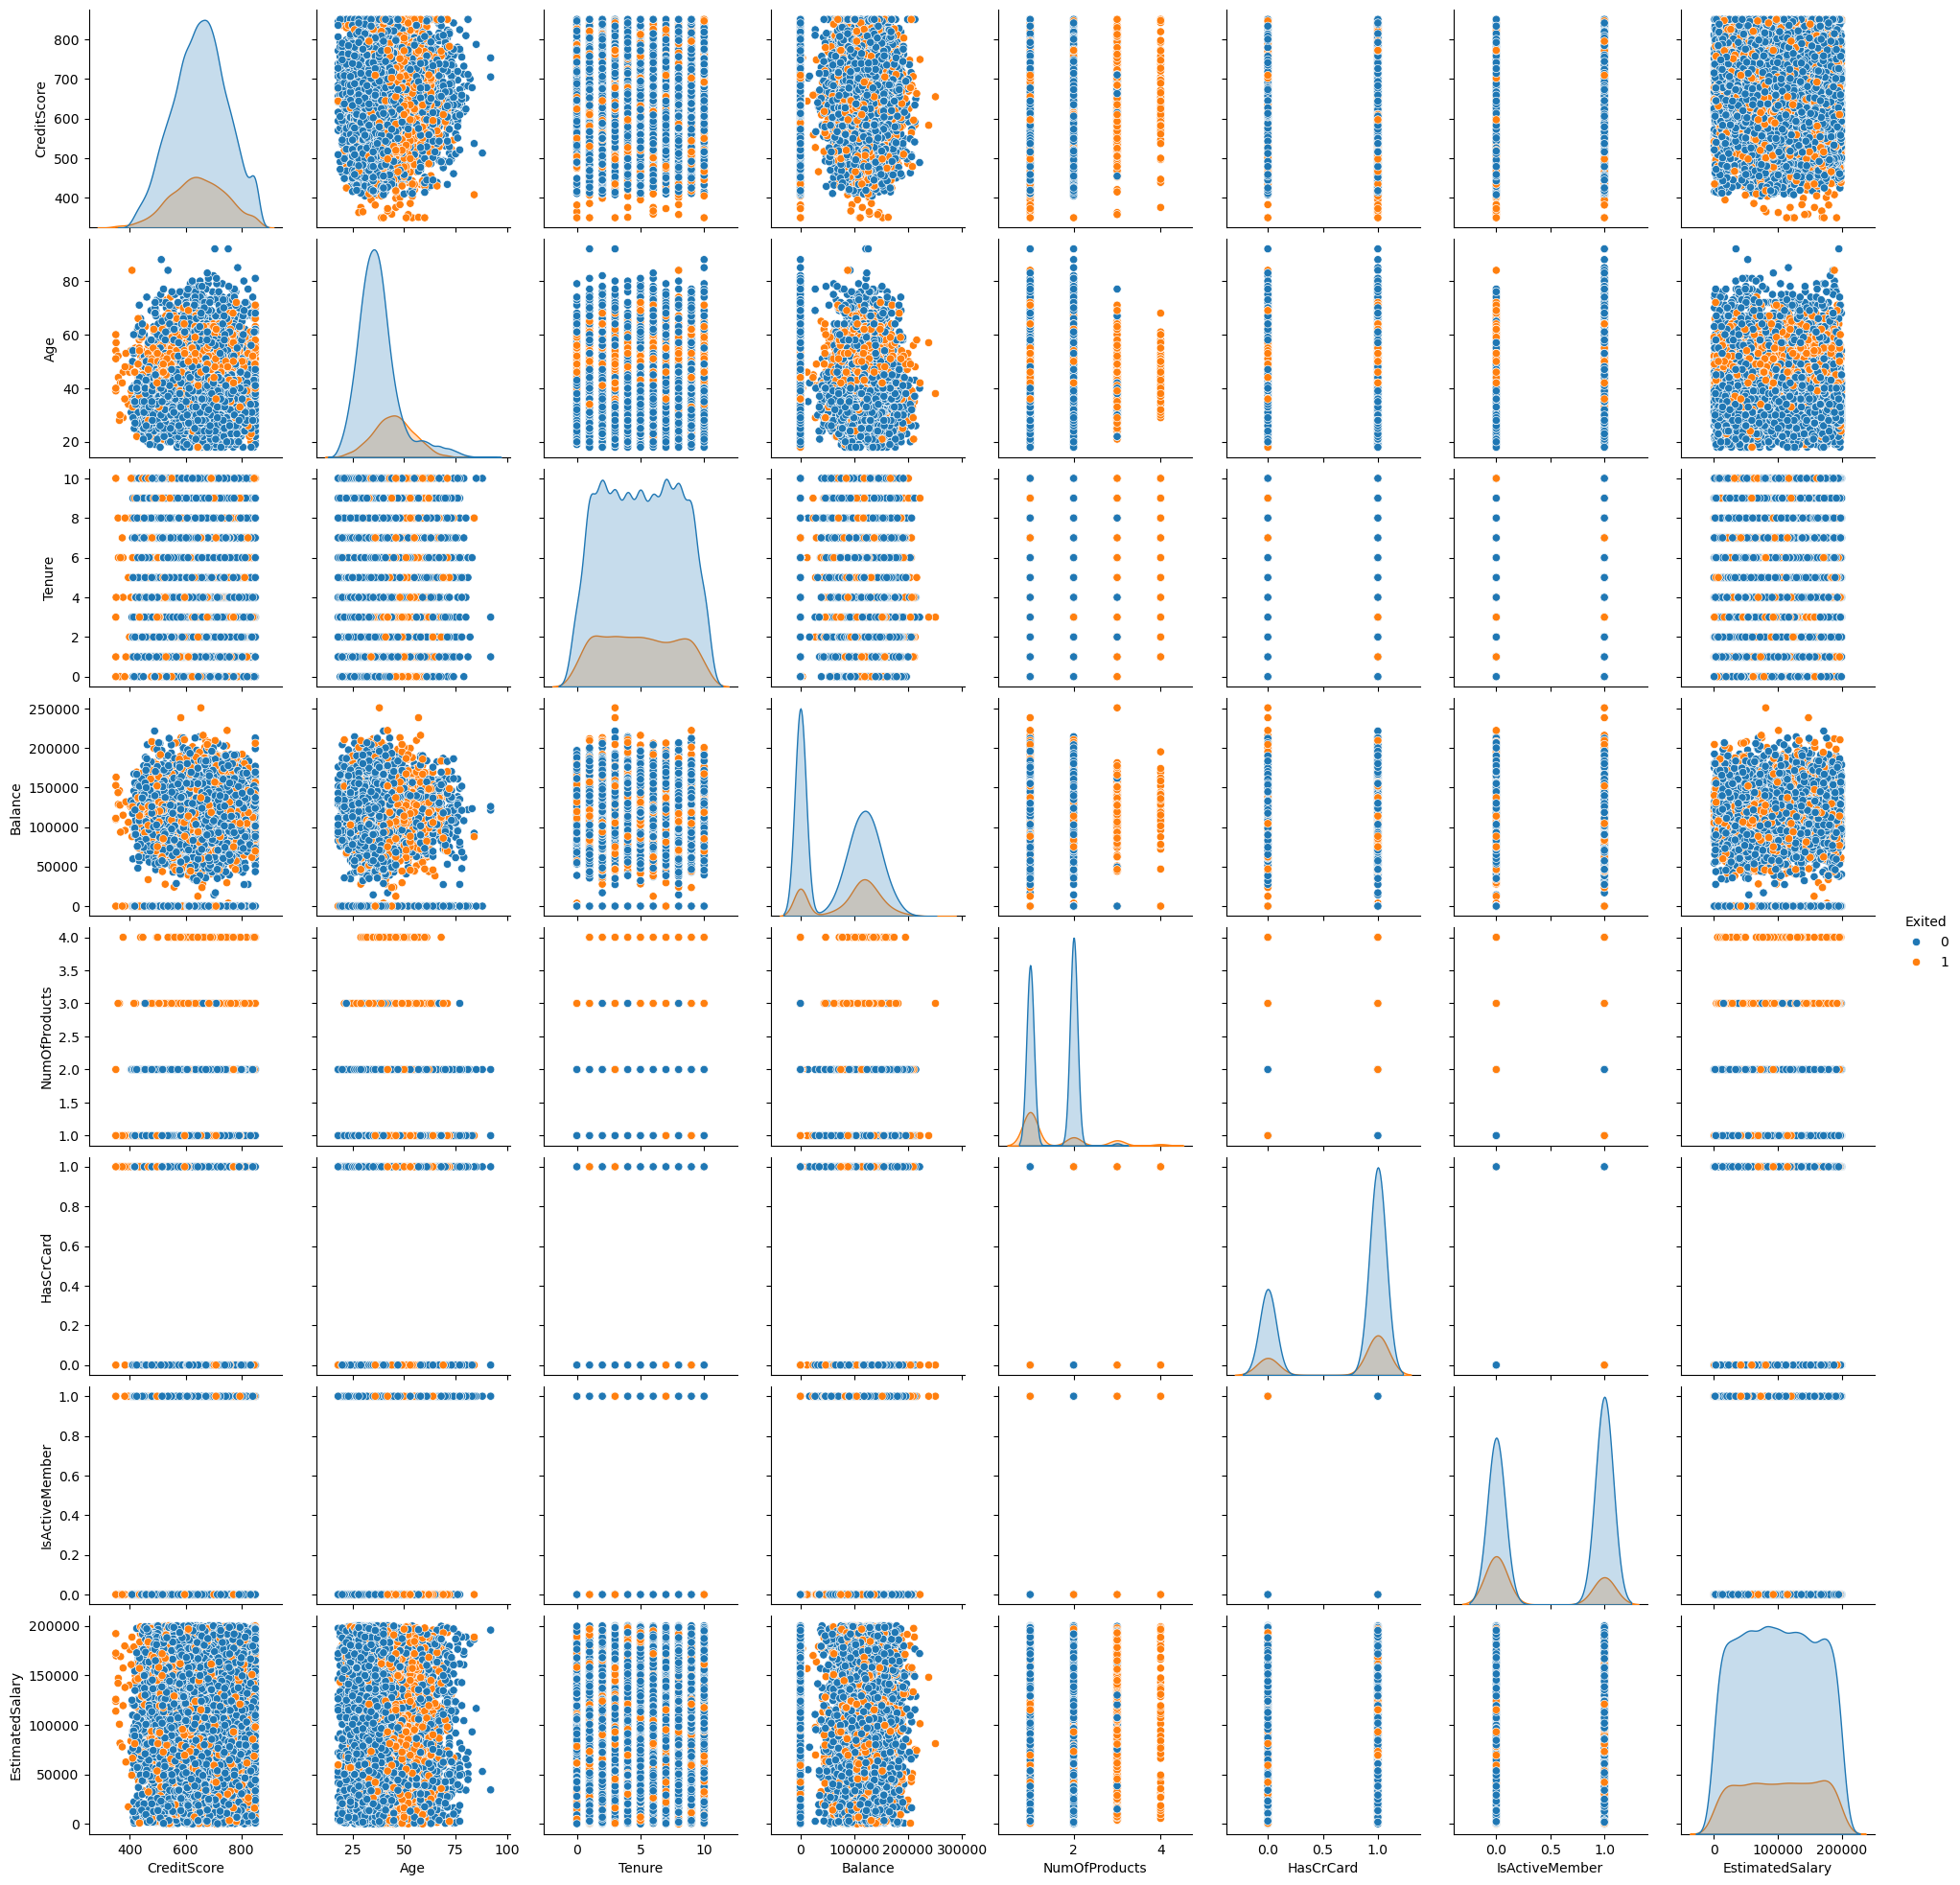

In [7]:
# limiting the data

df_v = df[['CreditScore','Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited']]

# visualizing 
g = sns.pairplot(df_v,hue='Exited')

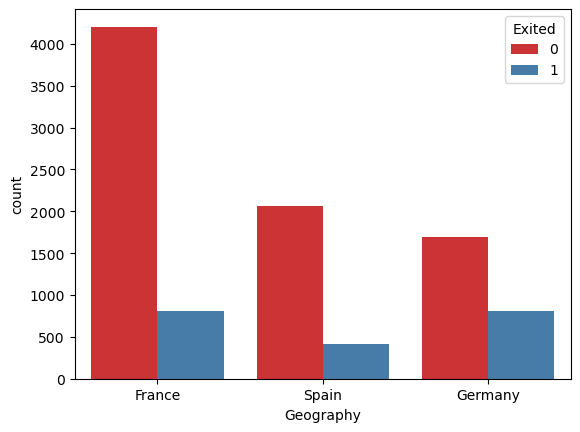

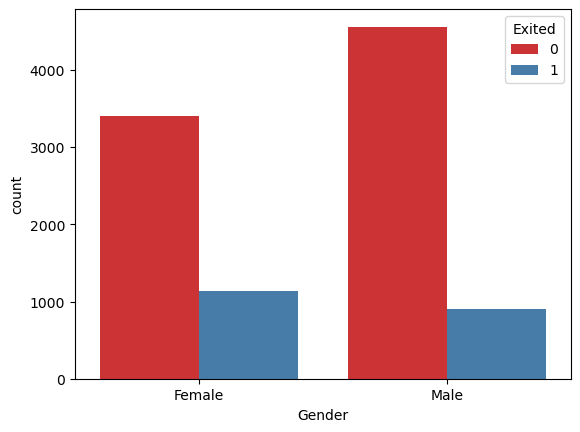

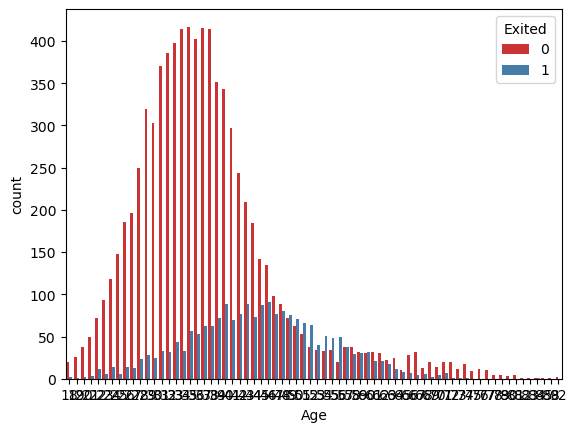

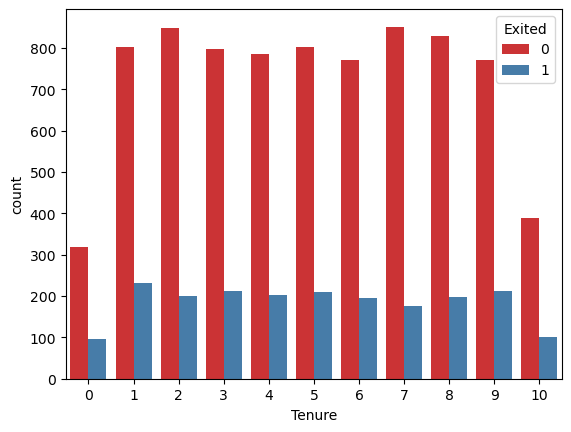

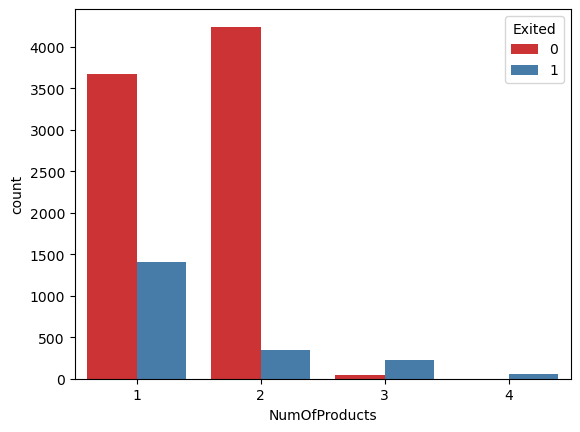

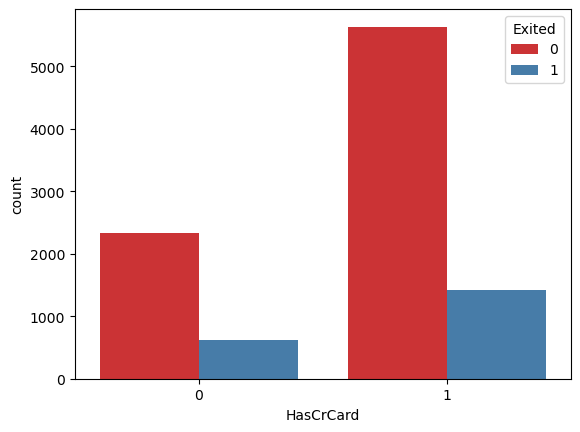

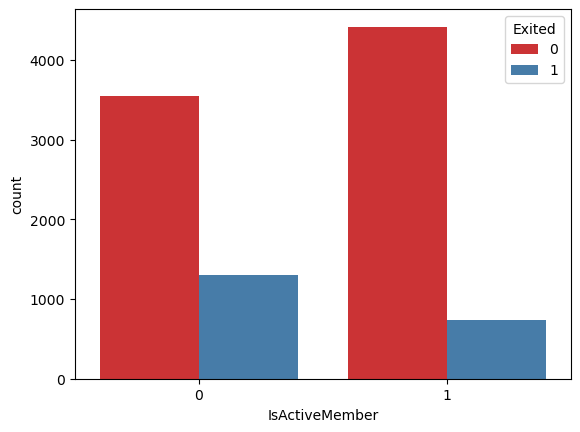

In [8]:
# InvestingaTE ALL the Feature by our y
feature = ['Geography', 'Gender', 'Age', 'Tenure', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember']

for f in feature:
    plt.figure()
    ax = sns.countplot(x = f,data=df_v,hue='Exited',palette='Set1')

In [9]:
# Investigating the distribution of all Numerical values

# identifying all numeric columns

numerics = ['int16','int32','int64','float16','float32','float64']
n_variable = df_v.select_dtypes(include=numerics).columns



The median is : 652.0


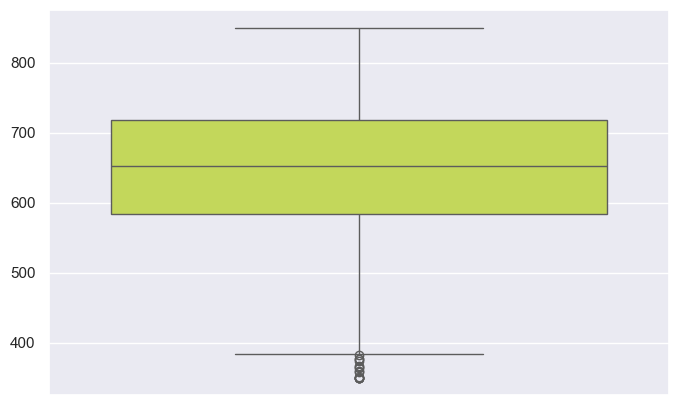

The median is : 37.0


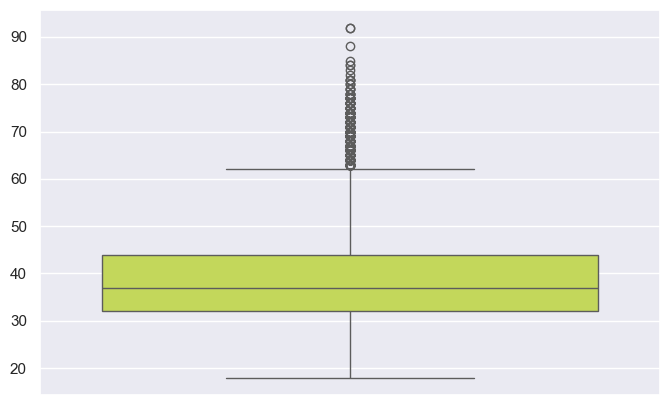

The median is : 5.0


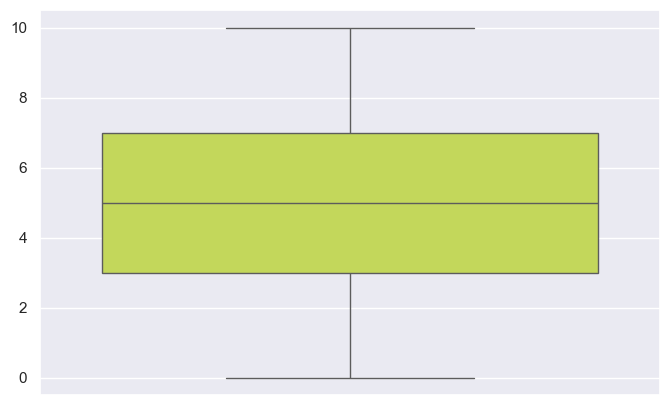

The median is : 97198.54000000001


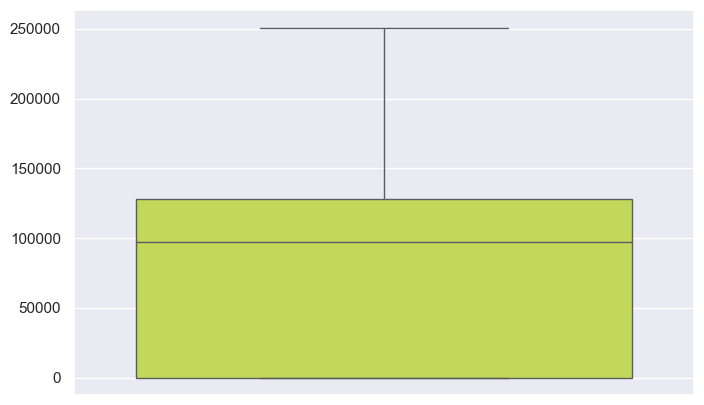

The median is : 1.0


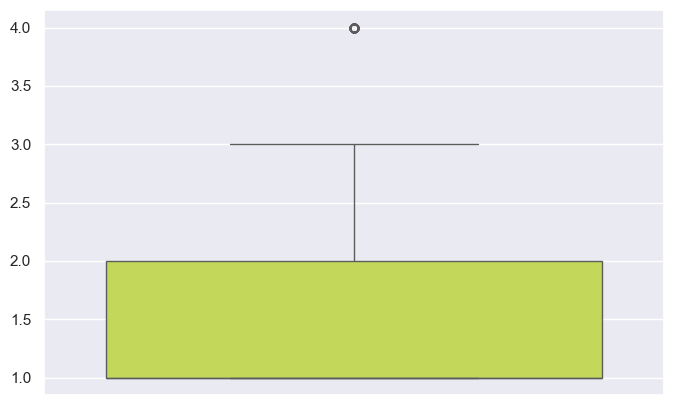

The median is : 1.0


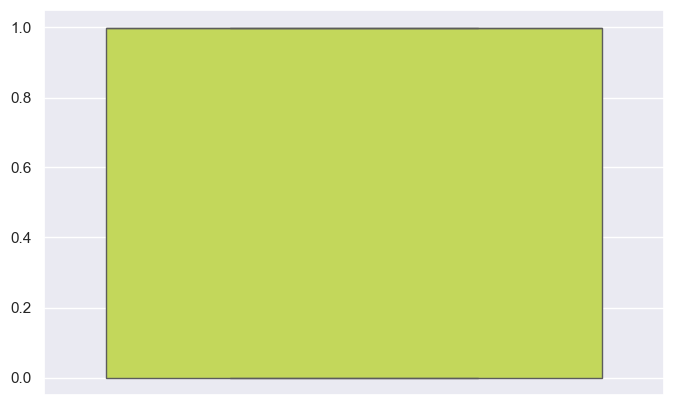

The median is : 1.0


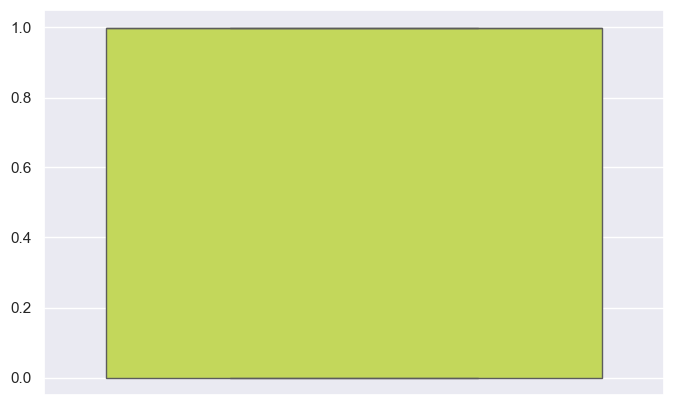

The median is : 100193.915


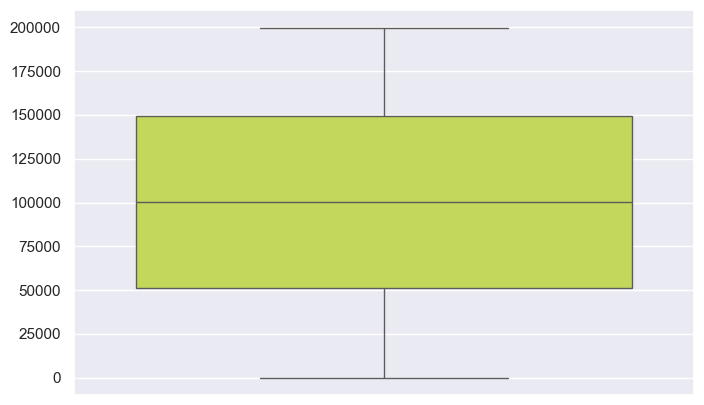

The median is : 0.0


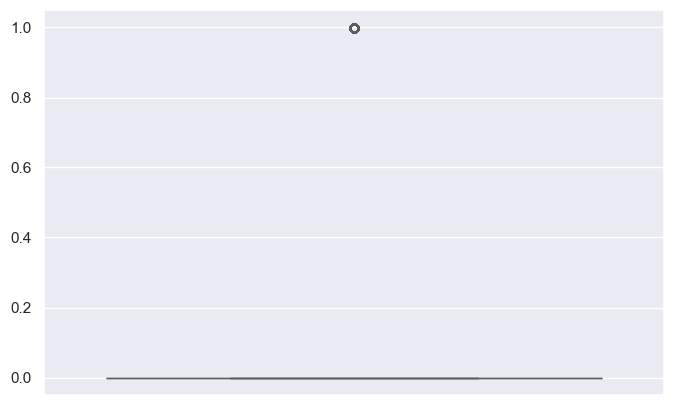

In [10]:
#increase the size of sns plot


sns.set(rc={'figure.figsize':(8,5)})

for c in n_variable:
    x = df_v[c].values
    ax = sns.boxplot(x,color = '#D1EC46')
    print("The median is :",df_v[c].median())
    plt.show()

## Preparing the final DF

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [12]:
# Making categorical variables into numeric representation
new_data = pd.get_dummies(df_v, columns = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember'], dtype='int')

# Scaling our columns
scale_vars = ['CreditScore','EstimatedSalary','Tenure', 'Balance','Age', 'NumOfProducts']
scaler = MinMaxScaler()
new_data[scale_vars] = scaler.fit_transform(new_data[scale_vars])
new_data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,HasCrCard_0,HasCrCard_1,IsActiveMember_0,IsActiveMember_1
0,0.538,0.324324,0.2,0.000000,0.000000,0.506735,1,1,0,0,1,0,0,1,0,1
1,0.516,0.310811,0.1,0.334031,0.000000,0.562709,0,0,0,1,1,0,1,0,0,1
2,0.304,0.324324,0.8,0.636357,0.666667,0.569654,1,1,0,0,1,0,0,1,1,0
3,0.698,0.283784,0.1,0.000000,0.333333,0.469120,0,1,0,0,1,0,1,0,1,0
4,1.000,0.337838,0.2,0.500246,0.000000,0.395400,0,0,0,1,1,0,0,1,0,1


## Running XGBoost

In [13]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [14]:
# Feature (X) and Target (Y)
x = new_data.drop(columns=['Exited'])
y = new_data['Exited']

In [15]:
x

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,HasCrCard_0,HasCrCard_1,IsActiveMember_0,IsActiveMember_1
0,0.538,0.324324,0.2,0.000000,0.000000,0.506735,1,0,0,1,0,0,1,0,1
1,0.516,0.310811,0.1,0.334031,0.000000,0.562709,0,0,1,1,0,1,0,0,1
2,0.304,0.324324,0.8,0.636357,0.666667,0.569654,1,0,0,1,0,0,1,1,0
3,0.698,0.283784,0.1,0.000000,0.333333,0.469120,1,0,0,1,0,1,0,1,0
4,1.000,0.337838,0.2,0.500246,0.000000,0.395400,0,0,1,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.842,0.283784,0.5,0.000000,0.333333,0.481341,1,0,0,0,1,0,1,1,0
9996,0.332,0.229730,1.0,0.228657,0.000000,0.508490,1,0,0,0,1,0,1,0,1
9997,0.718,0.243243,0.7,0.000000,0.000000,0.210390,1,0,0,1,0,1,0,0,1
9998,0.844,0.324324,0.3,0.299226,0.333333,0.464429,0,1,0,0,1,0,1,1,0


In [17]:
# tain test split 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [18]:
# Initialize the xgbost model
model = XGBClassifier(use_label_encoder=False,eval_metric='logloss',random_state=42)
model.fit(x_train,y_train)

C:\Users\deppa\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [17:37:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [19]:
# Predictions
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

# Training and Testing Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")


Training Accuracy: 0.96
Testing Accuracy: 0.86


In [22]:
# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)
feature_importance

,Feature,Importance
4,NumOfProducts,0.288658
13,IsActiveMember_0,0.194039
1,Age,0.113240
7,Geography_Germany,0.099048
3,Balance,0.053883
9,Gender_Female,0.042302
6,Geography_France,0.041067
8,Geography_Spain,0.037478
0,CreditScore,0.034965
5,EstimatedSalary,0.033707


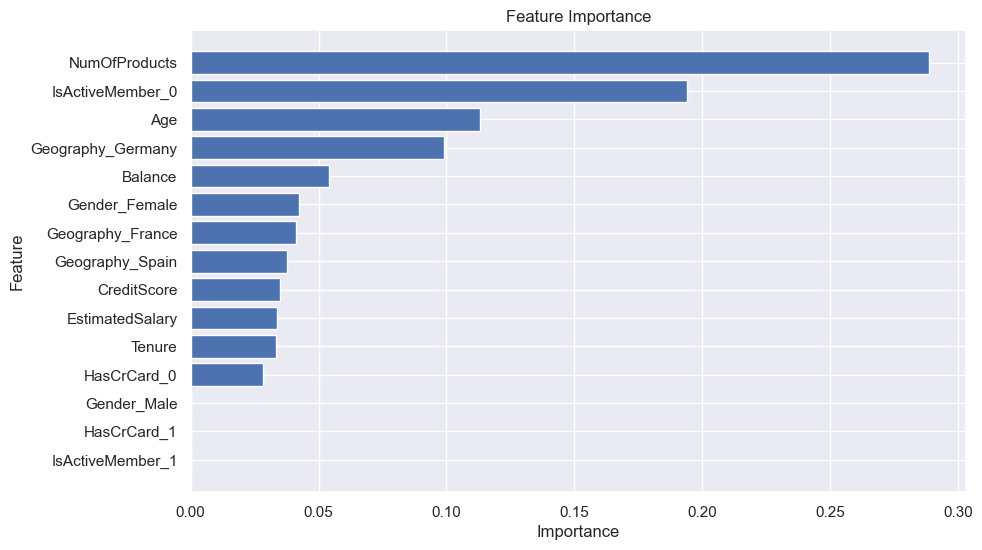

In [24]:
# Plotting feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"], align="center")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()



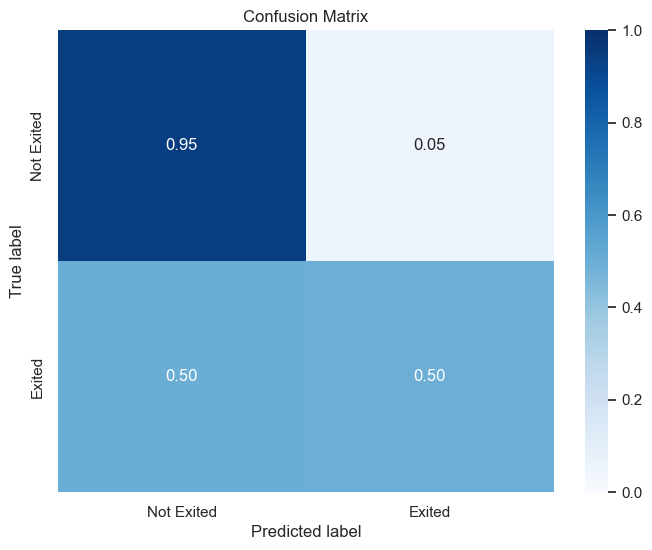

In [29]:
# confusion matrix plot function
def plot_confusion_metrix(cm, classes=None, title="Confusion Matrix"):
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        xticklabels=classes,
        yticklabels=classes,
        vmax=1, vmin=0,
        annot=True,
        cmap='Blues',
        fmt='.2f'   # <-- yaha sahi format
    )
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()
# caculate confusion metrix
cm = confusion_matrix(y_test,y_test_pred,normalize='true')
plot_confusion_metrix(cm,classes=['Not Exited','Exited'])

### 
We are not predicting Exited well....

C:\Users\deppa\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [18:29:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Accuracy: 0.97
Testing Accuracy: 0.85


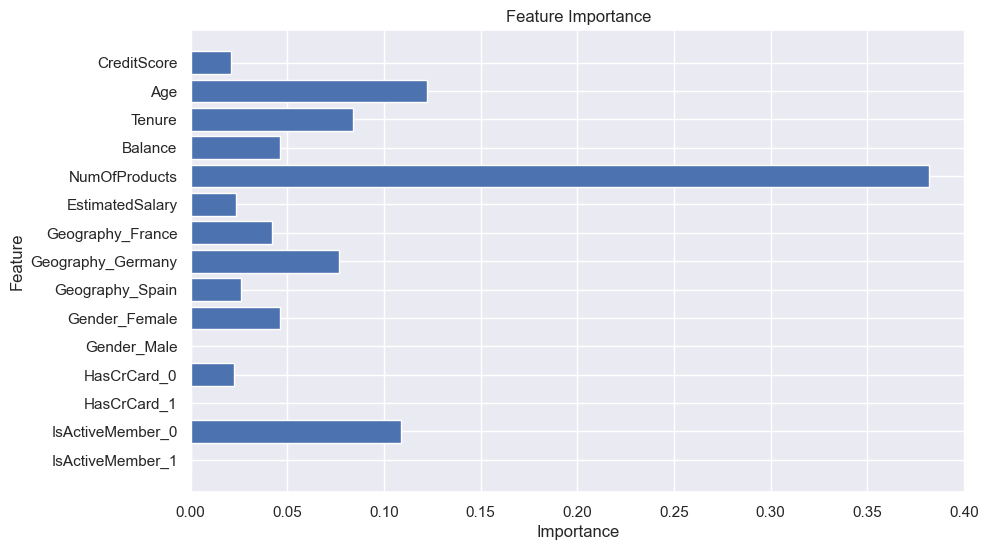

In [57]:
# 4. Re-Running XGBoost using SMOTE

from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Applying SMOTE to oversample the minority class in the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

# Initialize the XGBoost classifier
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_train_pred = model.predict(X_train_resampled)
y_test_pred = model.predict(x_test)

# Training and Testing Accuracy
train_accuracy = accuracy_score(y_train_resampled, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

# Plotting Feature Importance
feature_importance = model.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(x_train.columns, feature_importance, align='center')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

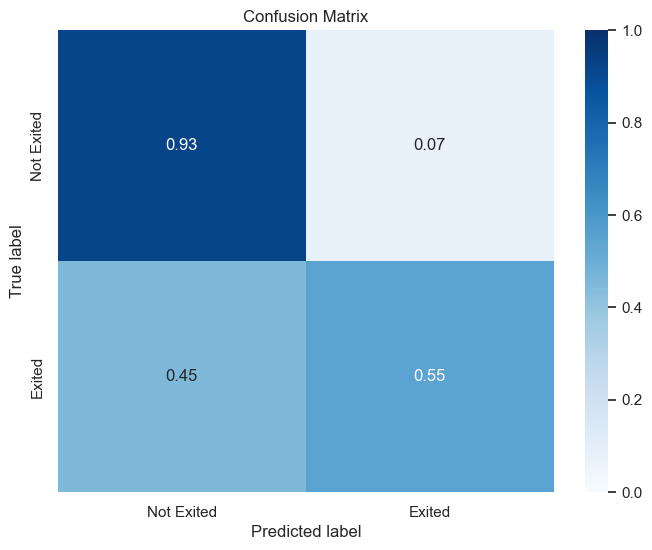

In [58]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred, normalize='true')
plot_confusion_matrix(cm, classes=["Not Exited", "Exited"])

In [2]:
import xgboost as xgb
from xgboost import plot_tree

# Export the first tree to graphviz format
dot_data = xgb.to_graphviz(model, num_trees=0)

# Save tree as a .dot file
dot_data.save("xgboost_tree.dot")

# OR directly visualize the tree
plt.figure(figsize=(30, 30))
plot_tree(model, num_trees=0)
plt.show()


Training Accuracy: 0.85
Testing Accuracy: 0.85


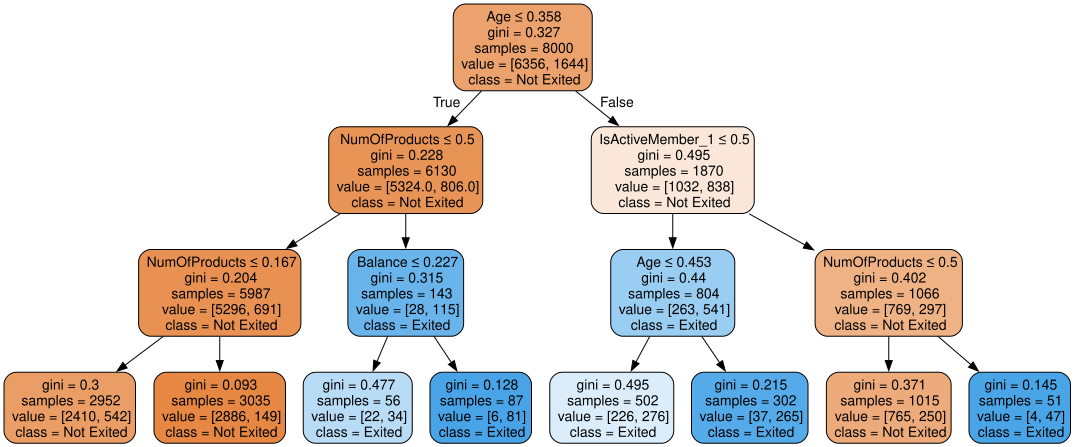

In [43]:
# Tree visual is not easy to read so we will train a simple DT to visual the tree:

from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz

# Train a Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42, max_depth=3)  # Adjust max_depth for simplicity
dt.fit(x_train, y_train)

# Predictions and evaluation
y_train_pred = dt.predict(x_train)
y_test_pred = dt.predict(x_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

# Export the decision tree to DOT format
dot_data = export_graphviz(
    dt,
    out_file=None,
    feature_names=new_data.drop("Exited", axis=1).columns,
    class_names=["Not Exited", "Exited"],
    filled=True,
    rounded=True,
    special_characters=True
)

# Visualize the tree using Graphviz
graph = graphviz.Source(dot_data)
graph

# Hyperparamaeter Tuning 

In [47]:
# its use the only original sklearn standard data

from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid for RandomizedSearchCV
param_grid = {
    "n_estimators": [100, 200, 300],  # Number of trees
    "max_depth": [3, 5, 7, 10],      # Maximum depth of a tree
    "learning_rate": [0.01, 0.05, 0.1, 0.2],  # Step size shrinkage
    "subsample": [0.6, 0.8, 1.0],    # Fraction of samples to grow trees
    "colsample_bytree": [0.6, 0.8, 1.0],  # Fraction of features for tree building
    "gamma": [0, 1, 5],              # Minimum loss reduction for split
    "reg_lambda": [1, 10, 50],       # L2 regularization term
}

# Initialize the base XGBoost classifier
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='auc', random_state=42)

# Apply RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=50,  # Number of parameter settings sampled
    scoring="f1",
    cv=3,  # 3-fold cross-validation
    random_state=42,
    verbose=1,
    n_jobs=-1  # Use all available cores
)

# Fit RandomizedSearchCV
random_search.fit(x_train, y_train)

# Get the best parameters and model
best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)

# Re-train the model with the best hyperparameters
best_model = random_search.best_estimator_
best_model.fit(x_train, y_train)

# Predictions
y_train_pred = best_model.predict(x_train)
y_test_pred = best_model.predict(x_test)
all_df_predict = best_model.predict(x)
all_df_predict_prob = best_model.predict_proba(x)

# Training and Testing Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)
feature_importance

Fitting 3 folds for each of 50 candidates, totalling 150 fits


C:\Users\deppa\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [18:14:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\deppa\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [18:14:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 1, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 5, 'colsample_bytree': 1.0}
Training Accuracy: 0.87
Testing Accuracy: 0.86


,Feature,Importance
1,Age,0.255230
13,IsActiveMember_0,0.176664
4,NumOfProducts,0.162106
7,Geography_Germany,0.081938
3,Balance,0.060135
9,Gender_Female,0.054267
6,Geography_France,0.039082
0,CreditScore,0.037760
2,Tenure,0.036247
5,EstimatedSalary,0.035159


In [61]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid for RandomizedSearchCV
param_grid = {
    "n_estimators": [100, 200, 300],  # Number of trees
    "max_depth": [3, 5, 7, 10],      # Maximum depth of a tree
    "learning_rate": [0.01, 0.05, 0.1, 0.2],  # Step size shrinkage
    "subsample": [0.6, 0.8, 1.0],    # Fraction of samples to grow trees
    "colsample_bytree": [0.6, 0.8, 1.0],  # Fraction of features for tree building
    "gamma": [0, 1, 5],              # Minimum loss reduction for split
    "reg_lambda": [1, 10, 50],       # L2 regularization term
}

# Initialize the base XGBoost classifier
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='auc', random_state=42)

# Apply RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=50,  # Number of parameter settings sampled
    scoring="f1",
    cv=3,  # 3-fold cross-validation
    random_state=42,
    verbose=1,
    n_jobs=-1  # Use all available cores
)

# Fit RandomizedSearchCV
random_search.fit(X_train_resampled, y_train_resampled)

# Get the best parameters and model
best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)

# Re-train the model with the best hyperparameters
best_model = random_search.best_estimator_
best_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_train_pred = best_model.predict(X_train_resampled)
y_test_pred = best_model.predict(x_test)
all_df_predict = best_model.predict(x)
all_df_predict_prob = best_model.predict_proba(x)

# Training and Testing Accuracy
train_accuracy = accuracy_score(y_train_resampled, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)
feature_importance

Fitting 3 folds for each of 50 candidates, totalling 150 fits


C:\Users\deppa\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [18:32:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Hyperparameters: {'subsample': 1.0, 'reg_lambda': 10, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}


C:\Users\deppa\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [18:32:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Accuracy: 0.95
Testing Accuracy: 0.85


,Feature,Importance
4,NumOfProducts,0.470494
1,Age,0.106685
14,IsActiveMember_1,0.100500
13,IsActiveMember_0,0.068868
7,Geography_Germany,0.052449
2,Tenure,0.035618
3,Balance,0.029498
9,Gender_Female,0.025509
6,Geography_France,0.019157
8,Geography_Spain,0.018522


In [ ]:
def plot_confusion_matrix(cm, classes, title="Confusion Matrix"):
    """Plots a confusion matrix and auto-selects format."""
    plt.figure(figsize=(8, 6))
    
    # Check if matrix contains float values
    fmt = '.2f' if cm.dtype.kind == "f" else 'd'
    
    sns.heatmap(cm, 
                xticklabels=classes,
                yticklabels=classes,
                vmin=0, vmax=1 if fmt=='.2f' else cm.max(), 
                annot=True, cmap="Blues",
                fmt=fmt)
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()


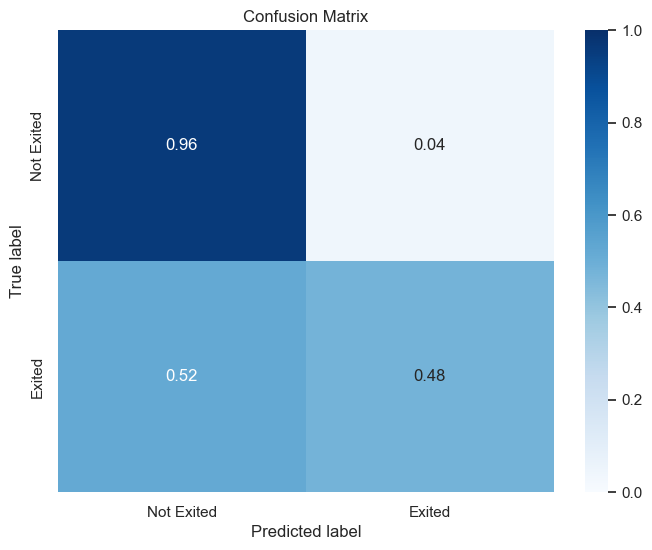

In [50]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred, normalize='true')
plot_confusion_matrix(cm, classes=["Not Exited", "Exited"])

# Storing Models and Results

In [51]:
# Adding the predictions back to the original dataset
df['Exited Prediction'] = all_df_predict
df['Exited Prediction Probability'] = all_df_predict_prob[:,1]

# Expoprting all the data with predictions
df.to_excel("bank_churn_data.xlsx")

In [52]:
# Storing the Feature Importances
feature_importance['Feature Importance Score'] = feature_importance['Importance'].round(4)
feature_importance.to_excel("feature_importance.xlsx")

In [53]:
# Save the best_model to a file
import pickle

with open('best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("Model saved successfully!")

# saving the scaler
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

Model saved successfully!


# . Streamlit App

In [3]:
from sklearn.preprocessing import MinMaxScaler
import streamlit as st
import pickle
import pandas as pd
import plotly.express as px

# Set Streamlit layout to wide
st.set_page_config(layout="wide")

# Load the trained model
with open('best_model.pkl', 'rb') as file:
    model = pickle.load(file)

# Load the MinMaxScaler
with open('scaler.pkl', 'rb') as file:
    scaler = pickle.load(file)

# Define the input features for the model
feature_names = [
    "CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
    "EstimatedSalary", "Geography_France", "Geography_Germany", "Geography_Spain",
    "Gender_Female", "Gender_Male", "HasCrCard_0", "HasCrCard_1",
    "IsActiveMember_0", "IsActiveMember_1"
]

# Columns requiring scaling
scale_vars = ["CreditScore", "EstimatedSalary", "Tenure", "Balance", "Age", "NumOfProducts"]

# Updated default values
default_values = [
    600, 30, 2, 8000, 2, 60000,
    True, False, False, True, False, False, True, False, True
]

# Sidebar setup
st.sidebar.image("Pic 1.png", use_column_width=True)  # Display Pic 1
st.sidebar.header("User Inputs")

# Collect user inputs
user_inputs = {}
for i, feature in enumerate(feature_names):
    if feature in scale_vars:
        user_inputs[feature] = st.sidebar.number_input(
            feature, value=default_values[i], step=1 if isinstance(default_values[i], int) else 0.01
        )
    elif isinstance(default_values[i], bool):
        user_inputs[feature] = st.sidebar.checkbox(feature, value=default_values[i])
    else:
        user_inputs[feature] = st.sidebar.number_input(
            feature, value=default_values[i], step=1
        )

# Convert inputs to a DataFrame
input_data = pd.DataFrame([user_inputs])

# Apply MinMaxScaler to the required columns
input_data_scaled = input_data.copy()
input_data_scaled[scale_vars] = scaler.transform(input_data[scale_vars])

# App Header
st.image("Pic 2.png", use_column_width=True)  # Display Pic 2
st.title("Customer Churn Prediction")

# Page Layout
left_col, right_col = st.columns(2)

# Left Page: Feature Importance
with left_col:
    st.header("Feature Importance")
    # Load feature importance data from the Excel file
    feature_importance_df = pd.read_excel("feature_importance.xlsx", usecols=["Feature", "Feature Importance Score"])
    # Plot the feature importance bar chart
    fig = px.bar(
        feature_importance_df.sort_values(by="Feature Importance Score", ascending=False),
        x="Feature Importance Score",
        y="Feature",
        orientation="h",
        title="Feature Importance",
        labels={"Feature Importance Score": "Importance", "Feature": "Features"},
        width=400,  # Set custom width
        height=500  # Set custom height
    )
    st.plotly_chart(fig)

# Right Page: Prediction
with right_col:
    st.header("Prediction")
    if st.button("Predict"):
        # Get the predicted probabilities and label
        probabilities = model.predict_proba(input_data_scaled)[0]
        prediction = model.predict(input_data_scaled)[0]
        # Map prediction to label
        prediction_label = "Churned" if prediction == 1 else "Retain"

        # Display results
        st.subheader(f"Predicted Value: {prediction_label}")
        st.write(f"Predicted Probability: {probabilities[1]:.2%} (Churn)")
        st.write(f"Predicted Probability: {probabilities[0]:.2%} (Retain)")
        # Display a clear output for the prediction
        st.markdown(f"### Output: **{prediction_label}**")

# Streamlit run churn_pred.py